# End-to-End Showcase of the Compression Pipeline

In [1]:
%load_ext autoreload
%autoreload 2

In [123]:
import os
import numpy as np
import matplotlib.pyplot as plt

from src.data import load_clip, save_clip, print_json_structure, extract_tracks

from src.compression.clip import ClipCompressor
from src.compression.baseline import RawBase64Compressor, QuantizeCompressor
from src.compression.blendshapes import BlendShapesSchemeCompressor

from src.eval import memory_saving_matrix

In [3]:
CLIP_IDX = 73

---
## Load Original Clip

In [4]:
orig_path = f"data/json/clip_{CLIP_IDX}.json"
orig_clip = load_clip(orig_path)

print_json_structure(orig_clip)

_id:
    $oid: <str>
animationClip:
    name: <str>
    duration: <float>
    tracks: [ 671 entries of
        name: <str>
        times: [ ~321 entries of <float> ]
        values: [ ~1284 entries of <float> ]
        type: <str>
    ]
    uuid: <str>
    blendMode: <int>
recordDate: <int>


---
## Baseline Compressions

In [5]:
rb64_com = ClipCompressor(
    blendshapes_compressor=RawBase64Compressor(type_name="number"),
    quaternions_compressor=RawBase64Compressor(type_name="quaternion"),
)

rb64_path = f"out/rb64/clip_{CLIP_IDX}_rb64.json"
rb64_clip = rb64_com.compress(orig_clip)
save_clip(rb64_clip, rb64_path)

print_json_structure(rb64_clip)

_id:
    $oid: <str>
animationClip:
    name: <str>
    duration: <float>
    uuid: <str>
    blendMode: <int>
    blendshape_tracks_data:
        compression_type: <str>
        type_name: <str>
        tracks: [ 624 entries of
            name: <str>
            times_b64: <str>
            values_b64: <str>
        ]
    quaternion_tracks_data:
        compression_type: <str>
        type_name: <str>
        tracks: [ 47 entries of
            name: <str>
            times_b64: <str>
            values_b64: <str>
        ]
recordDate: <int>


In [6]:
quan_com = ClipCompressor(
    blendshapes_compressor=QuantizeCompressor(type_name="number"),
    quaternions_compressor=QuantizeCompressor(type_name="quaternion"),
)

quan_path = f"out/quan/clip_{CLIP_IDX}_quan.json"
quan_clip = quan_com.compress(orig_clip)
save_clip(quan_clip, quan_path)

print_json_structure(quan_clip)

_id:
    $oid: <str>
animationClip:
    name: <str>
    duration: <float>
    uuid: <str>
    blendMode: <int>
    blendshape_tracks_data:
        compression_type: <str>
        type_name: <str>
        q_bits: <int>
        tracks: [ 624 entries of
            name: <str>
            q_times:
                codes_b64: <str>
                scale: <float64>
                zero: <float64>
            q_values:
                codes_b64: <str>
                scale: <float64>
                zero: <float64>
        ]
    quaternion_tracks_data:
        compression_type: <str>
        type_name: <str>
        q_bits: <int>
        tracks: [ 47 entries of
            name: <str>
            q_times:
                codes_b64: <str>
                scale: <float64>
                zero: <float64>
            q_values:
                codes_b64: <str>
                scale: <float64>
                zero: <float64>
        ]
recordDate: <int>


---
## Blendshapes Scheme

In [147]:
bsch_com = ClipCompressor(
    blendshapes_compressor=BlendShapesSchemeCompressor(type_name="number", decimation_thres=0),
    quaternions_compressor=QuantizeCompressor(type_name="quaternion"),
)

bsch_path = f"out/bsch/clip_{CLIP_IDX}_bsch.json"
bsch_clip = bsch_com.compress(orig_clip)
save_clip(bsch_clip, bsch_path)

print_json_structure(bsch_clip)

_id:
    $oid: <str>
animationClip:
    name: <str>
    duration: <float>
    uuid: <str>
    blendMode: <int>
    blendshape_tracks_data:
        q_bits: <int>
        f_fps: <int>
        groups: [ 48 entries of
            type: <str>
            names: [ ~12 entries of <str> ]
            f_times: <str>
            q_values:
                codes: <str>
                scale: <float64>
                zero: <float64>
        ]
    quaternion_tracks_data:
        compression_type: <str>
        type_name: <str>
        q_bits: <int>
        tracks: [ 47 entries of
            name: <str>
            q_times:
                codes_b64: <str>
                scale: <float64>
                zero: <float64>
            q_values:
                codes_b64: <str>
                scale: <float64>
                zero: <float64>
        ]
recordDate: <int>


---
## Evaluation

In [152]:
paths = [orig_path, rb64_path, quan_path, bsch_path]
names = ["Original", "RawBase64", "DirectQuantize", "BlendshapesScheme"]

print("===== MEMOEY USAGES =====\n")
for p, n in zip(paths, names):
    if n == "Original":
        blendshapes = extract_tracks(orig_clip["animationClip"]["tracks"], type="number")
        quaternions = extract_tracks(orig_clip["animationClip"]["tracks"], type="quaternion")

    else:
        clip = load_clip(p)
        blendshapes = clip["animationClip"].pop("blendshape_tracks_data", None)
        quaternions = clip["animationClip"].pop("quaternion_tracks_data", None)

    save_clip(blendshapes, "out/temp/blendshapes.json")
    save_clip(quaternions, "out/temp/quaternions.json")
    blendshapes_size = os.path.getsize("out/temp/blendshapes.json") // 1024
    quaternions_size = os.path.getsize("out/temp/quaternions.json") // 1024
    ratio = blendshapes_size / (blendshapes_size + quaternions_size)

    str1 = f"{n:<20} : {f"{os.path.getsize(p) // 1024:,}" + " KB":<10} | "
    str2 = f" blendshapes size: {f"{blendshapes_size:,}" + " KB":<9} | "
    str3 = f" quaternions size: {f"{quaternions_size:,}" + " KB":<9} | "
    str5 = f"({round(100 * ratio)} / {round(100 * (1 - ratio))})"

    print(str1 + str2 + str3 + str5)

===== MEMOEY USAGES =====

Original             : 14,582 KB  |  blendshapes size: 9,237 KB  |  quaternions size: 2,507 KB  | (79 / 21)
RawBase64            : 3,852 KB   |  blendshapes size: 3,034 KB  |  quaternions size: 791 KB    | (79 / 21)
DirectQuantize       : 796 KB     |  blendshapes size: 611 KB    |  quaternions size: 115 KB    | (84 / 16)
BlendshapesScheme    : 215 KB     |  blendshapes size: 86 KB     |  quaternions size: 115 KB    | (43 / 57)


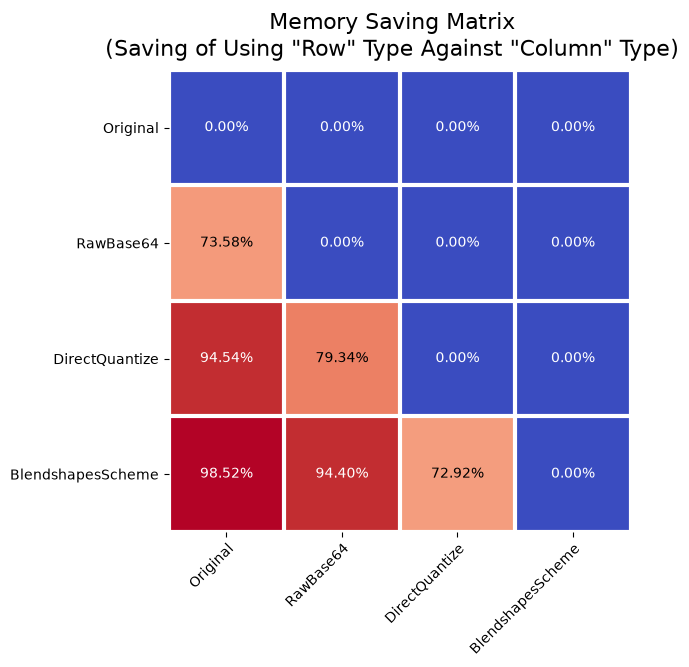

In [149]:
matrix = memory_saving_matrix(paths=paths, names=names, clip_negs=True).values
n = len(names)

fig, ax = plt.subplots(1, 1, figsize=(6,6))

im = ax.imshow(matrix, cmap="coolwarm")
# cbar = ax.figure.colorbar(im, ax=ax)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(names, rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticklabels(names)

for i in range(n):
    for j in range(n):
        text_color = "white" if np.abs(matrix[i, j] - 50) > 30 else "black"
        ax.text(j, i, f"{matrix[i, j]:.2f}%",
                ha="center", va="center", color=text_color)

ax.spines[:].set_visible(False)
ax.set_xticks(np.arange(matrix.shape[1]+1)-.5, minor=True)
ax.set_yticks(np.arange(matrix.shape[0]+1)-.5, minor=True)
ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
ax.tick_params(which="minor", bottom=False, left=False)

fig.suptitle("Memory Saving Matrix\n(Saving of Using \"Row\" Type Against \"Column\" Type)", fontsize=16)
plt.show()

plt.show()